# Fig 4 — E3 ABR composability under unfiltered + naive

Exact mirror of Fig 5's layout but for E3 (unfiltered + naive)
instead of E4 (filtered + aligned). 13 ABR configs × 3 bandwidth
profiles × 5 runs = 195 cells.

Each row isolates a single ABR rule (or, for `none`, no rule at all);
all configs pin the join rung to the middle of the ladder (1200k).

Heat map: avg delivered bitrate (kbps).
Right strip: max |playhead gap| per cell — under naive switching the
gap tracks the buffer occupancy at switch time, so unlike Fig 5 the
distribution will sit well above the 1-GOP envelope.

Robust to missing E3 data: cells with no runs render as "—".

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _data import (
    E4_COL_ORDER,
    E4_ROW_ORDER,
    RESULTS_ROOT,
    compute_avg_delivered_bitrate_kbps,
    load_aggregate,
)
from _style import (
    GOP_DURATION_MS,
    TEXT_WIDTH_IN,
    apply_acm_style,
)

apply_acm_style()


def e3_avg_bitrate_matrix() -> pd.DataFrame:
    """12x3 matrix of mean delivered bitrate (kbps) per (abr_config, profile)
    for the E3 experiment. Mirrors e4_avg_bitrate_matrix from _data.py but
    filters on experiment == 'e3'.
    """
    import json
    rows = []
    if not RESULTS_ROOT.exists():
        return pd.DataFrame(index=E4_ROW_ORDER, columns=E4_COL_ORDER, dtype=float)
    for summary_path in sorted(RESULTS_ROOT.rglob("summary.json")):
        try:
            data = json.loads(summary_path.read_text())
        except (json.JSONDecodeError, OSError):
            continue
        if data.get("experiment") != "e3":
            continue
        cell_id = data.get("cell_id")
        if not cell_id:
            continue
        bitrate = compute_avg_delivered_bitrate_kbps(summary_path.parent)
        rows.append({"cell_id": cell_id, "bitrate_kbps": bitrate})
    if not rows:
        return pd.DataFrame(index=E4_ROW_ORDER, columns=E4_COL_ORDER, dtype=float)
    df = pd.DataFrame(rows)
    parsed = df["cell_id"].str.split("_", n=1, expand=True)
    df["abr_config"] = parsed[0]
    df["profile"] = parsed[1]
    pivot = df.pivot_table(
        index="abr_config", columns="profile", values="bitrate_kbps", aggfunc="mean"
    )
    return pivot.reindex(index=E4_ROW_ORDER, columns=E4_COL_ORDER)


def safe_load_aggregate(experiment: str) -> pd.DataFrame:
    try:
        return load_aggregate(experiment)
    except FileNotFoundError:
        return pd.DataFrame(columns=["cell_id", "max_playhead_gap_ms", "n_switches"])

In [2]:
bitrate_matrix = e3_avg_bitrate_matrix()
agg = safe_load_aggregate("e3")

GOP_DURATION_S = GOP_DURATION_MS / 1000.0

# Same reader-friendly display names used in the E4 figure so the
# two read as a paired result.
PROFILE_DISPLAY = {
    "stable1.5M":  "Stable\n1.5 Mbps",
    "step3M_500k": "Step\n3 to 0.5 Mbps",
    "sin600k_3M":  "Sinusoidal\n0.6 to 3 Mbps",
}
CONFIG_DISPLAY = {
    "none":     "None",
    "thrpt":    "Throughput",
    "bola":     "BOLA",
    "probe":    "Probe",
    "ins-buf":  "Insufficient buffer",
    "drain":    "Buffer drain rate",
    "latency":  "Latency trend",
    "abandon":  "Abandon requests",
    "sw-hist":  "Switch history",
    "drops":    "Dropped frames",
    "all":      "All (no LoLP/L2A)",
    "lolp":     "LoLP",
    "l2a":      "L2A",
}

# Per-cell mean n_switches for the heat map text overlay.
if not agg.empty and "n_switches" in agg.columns:
    sw_means = agg.groupby("cell_id")["n_switches"].mean()
else:
    sw_means = pd.Series(dtype=float)


def cell_n_switches(config: str, profile: str) -> float:
    return float(sw_means.get(f"{config}_{profile}", float("nan")))

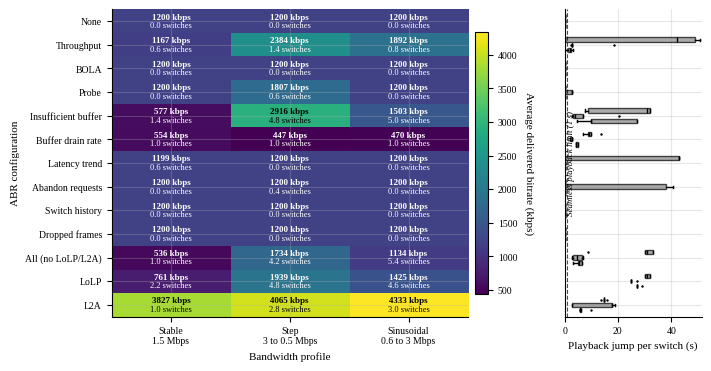

In [3]:
fig = plt.figure(figsize=(TEXT_WIDTH_IN, 3.6), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[2.6, 1.0], wspace=0.08)
ax_heat = fig.add_subplot(gs[0, 0])
ax_strip = fig.add_subplot(gs[0, 1])

# Heat map.
masked = np.ma.masked_invalid(bitrate_matrix.values)
im = ax_heat.imshow(masked, cmap="viridis", aspect="auto",
                    interpolation="nearest", origin="upper")
ax_heat.set_xticks(range(len(E4_COL_ORDER)))
ax_heat.set_xticklabels(
    [PROFILE_DISPLAY.get(p, p) for p in E4_COL_ORDER],
    rotation=0, ha="center", fontsize=7,
)
ax_heat.set_yticks(range(len(E4_ROW_ORDER)))
ax_heat.set_yticklabels(
    [CONFIG_DISPLAY.get(c, c) for c in E4_ROW_ORDER],
    fontsize=7,
)
ax_heat.set_xlabel("Bandwidth profile")
ax_heat.set_ylabel("ABR configuration")

# Cell text overlays.
for i, row in enumerate(E4_ROW_ORDER):
    for j, col in enumerate(E4_COL_ORDER):
        bitrate = bitrate_matrix.iloc[i, j]
        if np.isnan(bitrate):
            ax_heat.text(j, i, "n/a", ha="center", va="center",
                         color="#999999", fontsize=7)
            continue
        rgba = im.cmap(im.norm(bitrate))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if luminance < 0.5 else "black"
        switches = cell_n_switches(row, col)
        ax_heat.text(j, i - 0.18, f"{bitrate:.0f} kbps",
                     ha="center", va="center",
                     color=text_color, fontsize=6.5, weight="bold")
        if not np.isnan(switches):
            ax_heat.text(j, i + 0.18, f"{switches:.1f} switches",
                         ha="center", va="center",
                         color=text_color, fontsize=6)

cbar = fig.colorbar(im, ax=ax_heat, shrink=0.85, pad=0.02)
cbar.set_label("Average delivered bitrate (kbps)",
               rotation=270, labelpad=12)

# Boxplot strip, converted from milliseconds to seconds.
strip_data = []
strip_positions = []
for i, config in enumerate(E4_ROW_ORDER):
    for j, profile in enumerate(E4_COL_ORDER):
        cell_id = f"{config}_{profile}"
        if agg.empty:
            continue
        gaps_ms = agg[agg["cell_id"] == cell_id]["max_playhead_gap_ms"].values
        if len(gaps_ms) == 0:
            continue
        gaps_s = gaps_ms / 1000.0
        x_pos = i + (j - 1) * 0.22
        strip_data.append(gaps_s)
        strip_positions.append(x_pos)

if strip_data:
    ax_strip.boxplot(
        strip_data, positions=strip_positions, vert=False, widths=0.18,
        patch_artist=True,
        boxprops={"facecolor": "#888888", "alpha": 0.7},
        medianprops={"color": "black", "linewidth": 1.0},
        flierprops={"marker": "+", "markersize": 2},
    )
    xmax_data = max((max(d) for d in strip_data if len(d)), default=1.3)
else:
    ax_strip.text(0.5, 0.5, "E3 pending\n(run + aggregate)",
                  ha="center", va="center", transform=ax_strip.transAxes,
                  fontsize=9, color="#666666", weight="bold",
                  bbox=dict(boxstyle="round,pad=0.5", facecolor="#F8F8F8",
                            edgecolor="#999999", linewidth=0.6))
    xmax_data = 1.3

# Threshold line and rotated label, matching the wording used in
# the boxplot, trace, and E4 figures.
ax_strip.axvline(GOP_DURATION_S, color="black", linestyle="--",
                 linewidth=0.8, alpha=0.7)
ax_strip.text(
    GOP_DURATION_S * 1.04, len(E4_ROW_ORDER) / 2 - 0.5,
    "Seamless playback limit (1 s)",
    fontsize=6.5, va="center", ha="left", rotation=90, style="italic",
)

ax_strip.set_xlabel("Playback jump per switch (s)")
ax_strip.set_xlim(0, max(1.3, xmax_data + 0.5))
ax_strip.set_ylim(len(E4_ROW_ORDER) - 0.5, -0.5)
ax_strip.set_yticks(range(len(E4_ROW_ORDER)))
ax_strip.set_yticklabels([])
ax_strip.tick_params(axis="y", length=0)

In [4]:
fig.savefig(Path.cwd().parent / "figures" / "fig4_e3_unfiltered_naive.pdf")
fig.savefig(Path.cwd().parent / "figures" / "fig4_e3_unfiltered_naive.png", dpi=200)